# EE624: Speech Technology 
## GMM-Based Isolated Digit Recognition


## Submitted by - Faisal ziyad Ahmed (254102311)

Project 2: Perform GMM based isolated digit recognition
•  Given the training and testing file lists, compute 39-dimensional MFCC features and learn a  
GMM having 16/32 mixtures for each of the isolated digits using training data.
•  Identify the digits in test data using the maximum likelihood rule over the trained GMMs  
and report the confusion matrix for the recognition task. 

### Imports

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

### Configuration


In [2]:
# ── UPDATE THIS PATH 
DATASET_PATH =  r"C:\Users\DELL\OneDrive\Desktop\Instructional materials\Speech technology\Project\Number"


DIGITS      = [str(i) for i in range(10)]   # '0' … '9'
SR          = 16000
N_MFCC      = 13
TEST_SIZE   = 0.3      # 30% test, 70% train
RANDOM_STATE = 42

# Both mixture counts will be evaluated and compared
MIXTURE_COUNTS = [16, 32]

### Feature Extraction (39-dim MFCC)

In [3]:
def extract_features(file_path):
    """Load wav, trim silence, return 39-dim MFCC matrix (T, 39)."""
    y, sr = librosa.load(file_path, sr=SR)
    y, _  = librosa.effects.trim(y)

    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    return np.vstack((mfcc, delta, delta2)).T   # shape: (frames, 39)

### Train / Test Split


In [4]:
def prepare_data():
    """Split each digit's files into train/test (70/30, fixed seed)."""
    train_files = {}
    test_files  = {}

    for digit in DIGITS:
        folder = os.path.join(DATASET_PATH, digit)
        files  = sorted([os.path.join(folder, f)
                         for f in os.listdir(folder)
                         if f.endswith(".wav")])

        train, test = train_test_split(
            files, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
        train_files[digit] = train
        test_files[digit]  = test
        print(f"  Digit {digit}: Train={len(train)}, Test={len(test)}")

    return train_files, test_files

print("Preparing train/test split...")
train_files, test_files = prepare_data()

Preparing train/test split...
  Digit 0: Train=17, Test=8
  Digit 1: Train=17, Test=8
  Digit 2: Train=16, Test=8
  Digit 3: Train=17, Test=8
  Digit 4: Train=17, Test=8
  Digit 5: Train=17, Test=8
  Digit 6: Train=17, Test=8
  Digit 7: Train=17, Test=8
  Digit 8: Train=17, Test=8
  Digit 9: Train=17, Test=8


### Train GMM Models

In [5]:
def train_gmm(train_files, n_mixtures):
    """Train one GMM per digit with the given number of mixture components."""
    models = {}
    print(f"\nTraining GMM-{n_mixtures}...")

    for digit in DIGITS:
        all_features = np.vstack([
            extract_features(f) for f in train_files[digit]
        ])

        gmm = GaussianMixture(
            n_components=n_mixtures,
            covariance_type='diag',
            max_iter=200,
            n_init=3,             # run EM 3 times, keep best
            random_state=RANDOM_STATE
        )
        gmm.fit(all_features)
        models[digit] = gmm
        print(f"  Digit {digit}: trained on {all_features.shape[0]} frames")

    return models

### Test GMM Models

In [6]:
def test_gmm(models, test_files):
    """Classify each test utterance using maximum log-likelihood."""
    y_true, y_pred = [], []

    for digit in DIGITS:
        for file in test_files[digit]:
            features   = extract_features(file)
            scores     = {d: models[d].score(features) for d in DIGITS}
            prediction = max(scores, key=scores.get)
            y_true.append(digit)
            y_pred.append(prediction)

    return np.array(y_true), np.array(y_pred)

### Per-model Results Function

In [7]:
def show_results(y_true, y_pred, n_mixtures):
    """Print confusion matrix, accuracy, and per-digit metrics."""
    cm  = confusion_matrix(y_true, y_pred, labels=DIGITS)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"  GMM-{n_mixtures} Results")
    print(f"{'='*50}")
    print(f"  Overall Accuracy : {acc*100:.2f}%")

    # ── Confusion Matrix Plot ──
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=DIGITS, yticklabels=DIGITS,
                cmap='Blues', linewidths=0.5)
    plt.xlabel('Predicted Digit')
    plt.ylabel('True Digit')
    plt.title(f'Confusion Matrix — GMM-{n_mixtures}\nAccuracy = {acc*100:.2f}%')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_gmm{n_mixtures}.png', dpi=150)
    plt.show()

    # ── Per-digit Precision / Recall / F1 ──
    prec = precision_score(y_true, y_pred, labels=DIGITS, average=None, zero_division=0)
    rec  = recall_score   (y_true, y_pred, labels=DIGITS, average=None, zero_division=0)
    f1   = f1_score       (y_true, y_pred, labels=DIGITS, average=None, zero_division=0)

    df = pd.DataFrame({
        'Digit'    : DIGITS,
        'Precision': prec.round(4),
        'Recall'   : rec.round(4),
        'F1-Score' : f1.round(4)
    })
    print("\nPer-digit Metrics:")
    print(df.to_string(index=False))

    # ── Macro Averages ──
    print(f"\nMacro Averages:")
    print(f"  Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score   (y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-score  : {f1_score       (y_true, y_pred, average='macro', zero_division=0):.4f}")

    return acc, df

### Run Both GMM-16 and GMM-32



Training GMM-16...
  Digit 0: trained on 386 frames
  Digit 1: trained on 361 frames
  Digit 2: trained on 257 frames
  Digit 3: trained on 298 frames
  Digit 4: trained on 333 frames
  Digit 5: trained on 323 frames
  Digit 6: trained on 350 frames
  Digit 7: trained on 356 frames
  Digit 8: trained on 981 frames
  Digit 9: trained on 358 frames

  GMM-16 Results
  Overall Accuracy : 96.25%


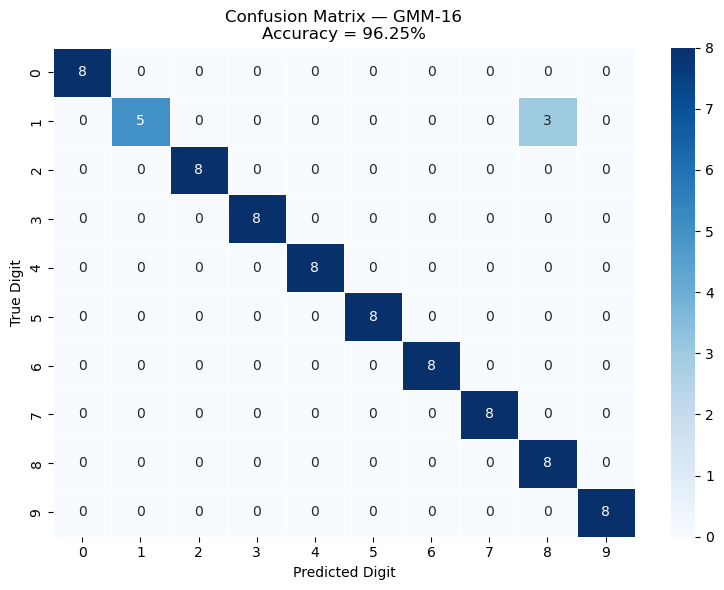


Per-digit Metrics:
Digit  Precision  Recall  F1-Score
    0     1.0000   1.000    1.0000
    1     1.0000   0.625    0.7692
    2     1.0000   1.000    1.0000
    3     1.0000   1.000    1.0000
    4     1.0000   1.000    1.0000
    5     1.0000   1.000    1.0000
    6     1.0000   1.000    1.0000
    7     1.0000   1.000    1.0000
    8     0.7273   1.000    0.8421
    9     1.0000   1.000    1.0000

Macro Averages:
  Precision : 0.9727
  Recall    : 0.9625
  F1-score  : 0.9611

Training GMM-32...
  Digit 0: trained on 386 frames
  Digit 1: trained on 361 frames
  Digit 2: trained on 257 frames
  Digit 3: trained on 298 frames
  Digit 4: trained on 333 frames
  Digit 5: trained on 323 frames
  Digit 6: trained on 350 frames
  Digit 7: trained on 356 frames
  Digit 8: trained on 981 frames
  Digit 9: trained on 358 frames

  GMM-32 Results
  Overall Accuracy : 96.25%


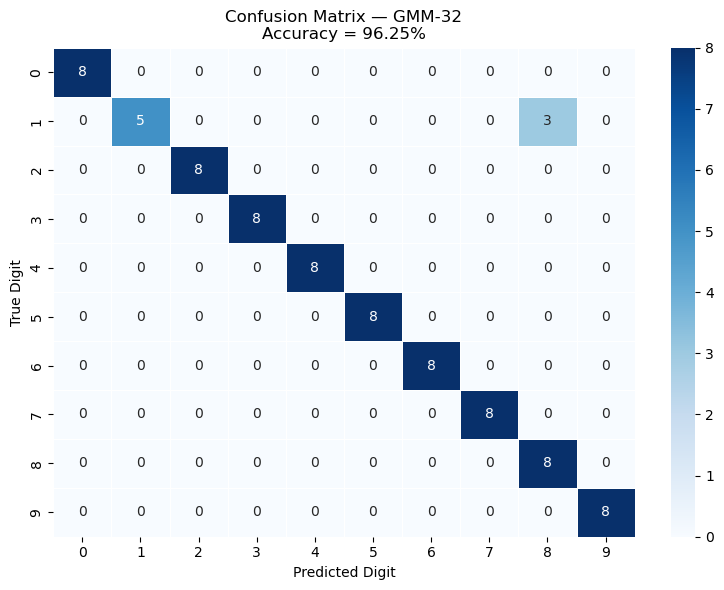


Per-digit Metrics:
Digit  Precision  Recall  F1-Score
    0     1.0000   1.000    1.0000
    1     1.0000   0.625    0.7692
    2     1.0000   1.000    1.0000
    3     1.0000   1.000    1.0000
    4     1.0000   1.000    1.0000
    5     1.0000   1.000    1.0000
    6     1.0000   1.000    1.0000
    7     1.0000   1.000    1.0000
    8     0.7273   1.000    0.8421
    9     1.0000   1.000    1.0000

Macro Averages:
  Precision : 0.9727
  Recall    : 0.9625
  F1-score  : 0.9611


In [8]:
results = {}  

for n_mix in MIXTURE_COUNTS:
    models          = train_gmm(train_files, n_mixtures=n_mix)
    y_true, y_pred  = test_gmm(models, test_files)
    acc, df_metrics = show_results(y_true, y_pred, n_mixtures=n_mix)
    results[n_mix]  = (y_true, y_pred, acc, df_metrics)

### Side-by-Side Confusion Matrix Comparison

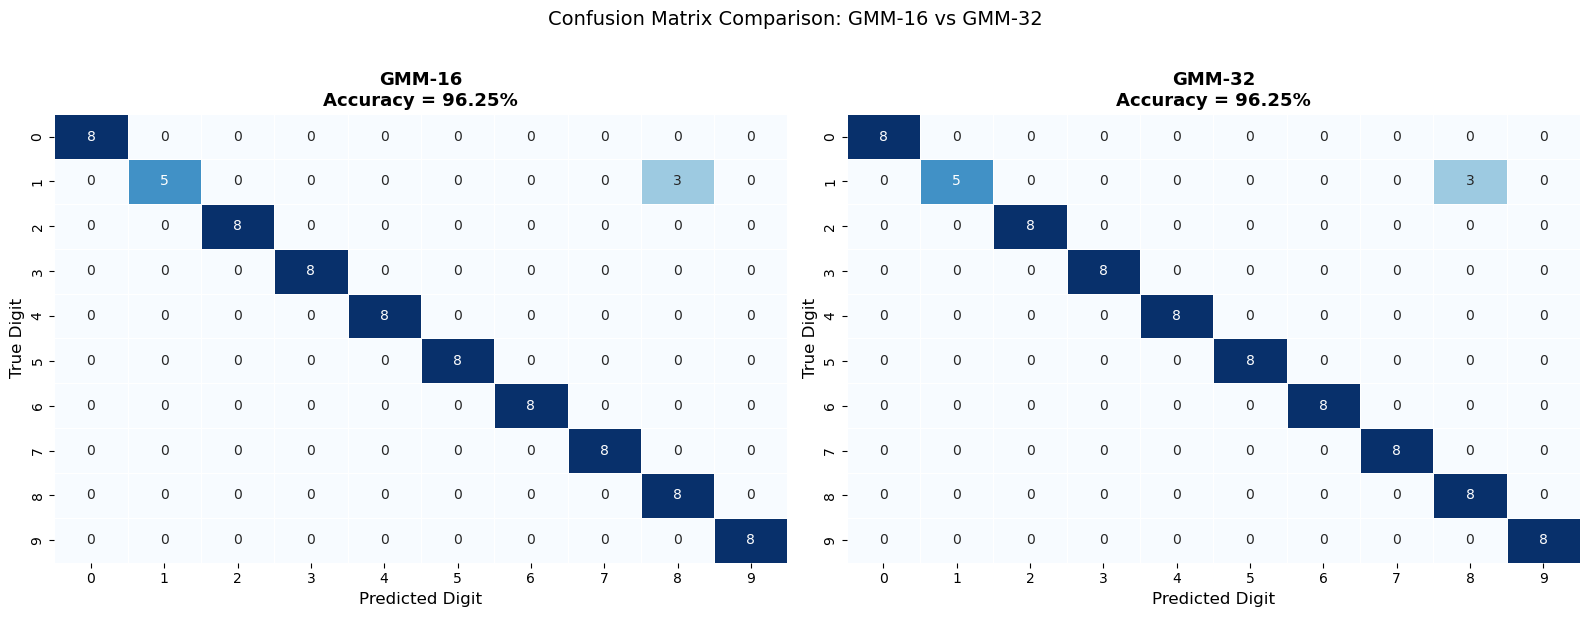

Saved: confusion_matrix_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, n_mix in zip(axes, MIXTURE_COUNTS):
    y_true, y_pred, acc, _ = results[n_mix]
    cm = confusion_matrix(y_true, y_pred, labels=DIGITS)

    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=DIGITS, yticklabels=DIGITS,
                cmap='Blues', linewidths=0.5,
                ax=ax, cbar=False)
    ax.set_xlabel('Predicted Digit', fontsize=12)
    ax.set_ylabel('True Digit', fontsize=12)
    ax.set_title(f'GMM-{n_mix}\nAccuracy = {acc*100:.2f}%', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison: GMM-16 vs GMM-32', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_comparison.png")

### Per-digit F1 Score Comparison (Bar Chart)

### Precision / Recall / F1 Comparison Table (side-by-side)

In [15]:
# Merge both metric tables into one for easy reading
merged = pd.DataFrame({'Digit': DIGITS})

for n_mix in MIXTURE_COUNTS:
    df = results[n_mix][3]
    merged[f'Prec-{n_mix}'] = df['Precision'].values
    merged[f'Rec-{n_mix}' ] = df['Recall'].values
    merged[f'F1-{n_mix}'  ] = df['F1-Score'].values

print("\nSide-by-Side Per-Digit Metrics (GMM-16 vs GMM-32):")
print(merged.to_string(index=False))

# Also show improvement column
merged['F1 Δ (32-16)'] = (merged['F1-32'] - merged['F1-16']).round(4)
print("\nF1-Score Change (GMM-32 minus GMM-16):")
print(merged[['Digit', 'F1-16', 'F1-32', 'F1 Δ (32-16)']].to_string(index=False))


Side-by-Side Per-Digit Metrics (GMM-16 vs GMM-32):
Digit  Prec-16  Rec-16  F1-16  Prec-32  Rec-32  F1-32
    0   1.0000   1.000 1.0000   1.0000   1.000 1.0000
    1   1.0000   0.625 0.7692   1.0000   0.625 0.7692
    2   1.0000   1.000 1.0000   1.0000   1.000 1.0000
    3   1.0000   1.000 1.0000   1.0000   1.000 1.0000
    4   1.0000   1.000 1.0000   1.0000   1.000 1.0000
    5   1.0000   1.000 1.0000   1.0000   1.000 1.0000
    6   1.0000   1.000 1.0000   1.0000   1.000 1.0000
    7   1.0000   1.000 1.0000   1.0000   1.000 1.0000
    8   0.7273   1.000 0.8421   0.7273   1.000 0.8421
    9   1.0000   1.000 1.0000   1.0000   1.000 1.0000

F1-Score Change (GMM-32 minus GMM-16):
Digit  F1-16  F1-32  F1 Δ (32-16)
    0 1.0000 1.0000           0.0
    1 0.7692 0.7692           0.0
    2 1.0000 1.0000           0.0
    3 1.0000 1.0000           0.0
    4 1.0000 1.0000           0.0
    5 1.0000 1.0000           0.0
    6 1.0000 1.0000           0.0
    7 1.0000 1.0000           0.0
    8 0.